# XGBoost residual correction MVP

Correct time-series forecast errors for `TARGET_GENERIC_EN` products.

- **Baseline features:** forecast, horizon, calendar, sales lags, product attrs
- **+ Business features:** last-complete-6-month event and activity counts (leakage-safe vs forecast origin)
- Notebook-only; does not write back to `results/`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _src = _root.parent / "src"
    _results = _root.parent / "src" / "data" / "results"
else:
    _src = _root / "src"
    _results = _root / "src" / "data" / "results"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from pkg.db.query.sales import load_sales_data
from pkg.db.query.dim_product import load_dim_product
from pkg.db.query.constants import TARGET_GENERIC_EN
from pkg.db.query.event_profile import load_event_count_by_product
from pkg.db.query.activity import load_activity_count_by_product

RESULTS_DIR = _results
print("results:", RESULTS_DIR)

# Incomplete Shamsi months to exclude from sales, forecasts, and training
INCOMPLETE_SHAMSI_MONTHS = {140505}


results: C:\Users\Mohajeri.K\MyProjects\Forecast\src\data\results


## Helpers (Shamsi month arithmetic)

In [2]:
def shamsi_add_months(ym: int, n: int) -> int:
    y, m = divmod(int(ym), 100)
    idx = y * 12 + (m - 1) + n
    y2, m0 = divmod(idx, 12)
    return y2 * 100 + (m0 + 1)


def shamsi_month_diff(ym_a: int, ym_b: int) -> int:
    """Months from ym_b to ym_a (ym_a - ym_b)."""
    ya, ma = divmod(int(ym_a), 100)
    yb, mb = divmod(int(ym_b), 100)
    return (ya * 12 + ma) - (yb * 12 + mb)


def last_complete_6m(origin_ym: int) -> tuple[int, int]:
    """Inclusive Shamsi window: origin-6 .. origin-1."""
    end = shamsi_add_months(origin_ym, -1)
    start = shamsi_add_months(origin_ym, -6)
    return start, end


assert last_complete_6m(140501) == (140407, 140412)
print("ok", last_complete_6m(140501))

ok (140407, 140412)


## Load sales and target products

In [4]:
sales_df = load_sales_data()
sales_df["date"] = sales_df["date"].astype(int)
sales_df["sales"] = pd.to_numeric(sales_df["sales"], errors="coerce")
sales_df = sales_df[~sales_df["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
print("excluded incomplete sales months:", sorted(INCOMPLETE_SHAMSI_MONTHS))

dim_product_df = load_dim_product()
target_products = dim_product_df[dim_product_df["GenericEN"].isin(TARGET_GENERIC_EN)].copy()
target_product_names = set(target_products["ProductTitleEN"].dropna().astype(str))

product_attrs = (
    target_products[["ProductTitleEN", "GenericEN", "Field", "ProductForm", "Provider"]]
    .drop_duplicates(subset=["ProductTitleEN"])
    .rename(columns={"ProductTitleEN": "product", "GenericEN": "generic"})
)

print("sales rows", len(sales_df), "target products", len(target_product_names))
product_attrs.head()

excluded incomplete sales months: [140505]
sales rows 30628 target products 69


,product,generic,Field,ProductForm,Provider
1,Maciza,Maciza,کاردیو متابولیک تزریقی,Pen,سیناژن
6,Xetarem,Xetarem,کانتراست مدیا,Vial,آلاشت
17,Fiorage M,Fiorage,زیبایی,Prefilled Syringe,اسپاد فارمد دارو
46,Lunaphil Volix,Lunaphil,زیبایی,Prefilled Syringe,اسپاد فارمد دارو
66,Beraksurf 4,Beraksurf,رسپیراتوری,Vial,پرسیس ژن


## Build forecast–actual panel

For each allowed quarter CSV, **extract each product's 15-month forecast**:
dedupe to one value per product–month, then keep that product's **last 15 months** in the file (history before the forecast is dropped).

Allowed files: `1403Q1`–`1403Q4`, `1404Q2`–`1404Q4`, `1405Q2`.
Then join actualized sales; overlapping quarter runs stay as separate rows.


In [5]:
# Explicit allowlist of usable TS forecast runs (excludes empty / placeholder quarters)
ALLOWED_FORECAST_QRTS = (
    "1403Q1",
    "1403Q2",
    "1403Q3",
    "1403Q4",
    "1404Q2",
    "1404Q3",
    "1404Q4",
    "1405Q2",
)
FORECAST_HORIZON_MONTHS = 15


def extract_product_forecast_window(df: pd.DataFrame, n_months: int = FORECAST_HORIZON_MONTHS) -> pd.DataFrame:
    """From one quarter CSV, extract each product's n-month forecast.

    Files may contain history before the forecast. For each product:
    1) collapse to one row per Shamsi month
    2) keep the last `n_months` months = the forecast window
    3) set origin = first month of that window, horizon = 1..n
    """
    meta_cols = [c for c in ("product_fa", "provider", "model", "dep", "status", "qrt") if c in df.columns]
    parts = []
    short = []
    for product, g in df.groupby("product", sort=False):
        agg_kw = {"forecast": ("forecast", "mean")}
        agg_kw.update({c: (c, "first") for c in meta_cols})
        row = g.groupby("date", as_index=False).agg(**agg_kw)
        row["product"] = product
        dates = sorted(row["date"].astype(int).tolist())
        if not dates:
            continue
        window = dates[-n_months:]
        if len(window) < n_months:
            short.append((product, len(window)))
        origin = int(window[0])
        gg = row[row["date"].isin(window)].copy()
        gg["origin"] = origin
        gg["horizon"] = [shamsi_month_diff(int(d), origin) + 1 for d in gg["date"]]
        parts.append(gg)
    out = pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0].copy()
    if short:
        print(f"  products with fewer than {n_months} months: {len(short)} (kept available months)")
    return out


def load_forecast_csvs(results_dir: Path, allowed_qrts=ALLOWED_FORECAST_QRTS) -> pd.DataFrame:
    """Load allowed quarter CSVs and extract each product's 15-month forecast."""
    frames = []
    missing = []
    for qrt in allowed_qrts:
        csv_path = results_dir / qrt / f"{qrt}_total_forecast.csv"
        if not csv_path.exists():
            missing.append(str(csv_path))
            continue
        df = pd.read_csv(csv_path)
        df["date"] = df["date"].astype(int)
        df["forecast"] = pd.to_numeric(df["forecast"], errors="coerce")
        df["qrt"] = qrt
        df = df[~df["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
        print(f"{qrt}: raw rows={len(df)} products={df['product'].nunique()}")
        df = extract_product_forecast_window(df, FORECAST_HORIZON_MONTHS)
        months_per = df.groupby("product")["date"].nunique()
        print(
            f"{qrt}: forecast window rows={len(df)} "
            f"products={df['product'].nunique()} "
            f"months/product~{months_per.mean():.1f}"
        )
        frames.append(df)
    if missing:
        print("missing allowed forecast files:", missing)
    if not frames:
        raise FileNotFoundError(f"No allowed forecast CSVs under {results_dir}")
    print("loaded forecast qrts:", [f["qrt"].iloc[0] for f in frames])
    return pd.concat(frames, ignore_index=True)


forecast_df = load_forecast_csvs(RESULTS_DIR)
forecast_df = forecast_df[forecast_df["product"].isin(target_product_names)].copy()

sales_agg = (
    sales_df.groupby(["product", "date"], as_index=False)["sales"]
    .sum()
)

panel = forecast_df.merge(sales_agg, on=["product", "date"], how="inner")
panel = panel[~panel["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
panel["residual"] = panel["sales"] - panel["forecast"]
panel = panel[(panel["horizon"] >= 1) & (panel["horizon"] <= FORECAST_HORIZON_MONTHS)].copy()

print("panel rows", len(panel), "products", panel["product"].nunique())
print("origins", sorted(panel["origin"].unique()))
print("qrts", sorted(panel["qrt"].unique()))
panel[["product", "qrt", "origin", "date", "horizon", "forecast", "sales", "residual"]].head()

1403Q1: raw rows=3679 products=247
  products with fewer than 15 months: 2 (kept available months)
1403Q1: forecast window rows=3679 products=247 months/product~14.9
1403Q2: raw rows=4305 products=285
1403Q2: forecast window rows=4275 products=285 months/product~15.0
1403Q3: raw rows=4485 products=299
1403Q3: forecast window rows=4485 products=299 months/product~15.0
1403Q4: raw rows=4470 products=298
1403Q4: forecast window rows=4470 products=298 months/product~15.0
1404Q2: raw rows=4700 products=334
  products with fewer than 15 months: 310 (kept available months)
1404Q2: forecast window rows=4700 products=334 months/product~14.1
1404Q3: raw rows=4746 products=339
  products with fewer than 15 months: 339 (kept available months)
1404Q3: forecast window rows=4746 products=339 months/product~14.0
1404Q4: raw rows=5026 products=359
  products with fewer than 15 months: 359 (kept available months)
1404Q4: forecast window rows=5026 products=359 months/product~14.0
1405Q2: raw rows=5404 pr

,product,qrt,origin,date,horizon,forecast,sales,residual
0,Aryotrust 150,1403Q1,140304,140304,1,6021.0,7689.0,1668.0
1,Aryotrust 150,1403Q1,140304,140305,2,6250.0,5550.0,-700.0
2,Aryotrust 150,1403Q1,140304,140306,3,6020.0,5631.0,-389.0
3,Aryotrust 150,1403Q2,140306,140306,1,6973.0,5631.0,-1342.0
4,Aryotrust 150,1403Q1,140304,140307,4,5943.0,4631.0,-1312.0


## Forecast vintage audit

Read-only diagnostics for whether `qrt`, inferred `origin`, and the extracted 15-month windows represent historical forecast vintages.

Re-reads allowlisted raw CSVs (does not change extraction or modeling). Anomalies are displayed explicitly — not silently fixed.

In [6]:
# --- Forecast vintage audit (read-only; does not modify forecast_df / panel) ---
from IPython.display import display


def _is_exact_n_consecutive(dates, origin: int, n: int = FORECAST_HORIZON_MONTHS) -> bool:
    dates = sorted(int(d) for d in dates)
    if len(dates) != n:
        return False
    expected = [shamsi_add_months(int(origin), i) for i in range(n)]
    return dates == expected


# 1) Raw CSV stats per product × qrt (source span + pre-aggregation duplicates)
raw_rows = []
for qrt in ALLOWED_FORECAST_QRTS:
    csv_path = RESULTS_DIR / qrt / f"{qrt}_total_forecast.csv"
    if not csv_path.exists():
        print(f"AUDIT missing raw file: {csv_path}")
        continue
    raw = pd.read_csv(csv_path)
    raw["date"] = raw["date"].astype(int)
    raw = raw[~raw["date"].isin(INCOMPLETE_SHAMSI_MONTHS)].copy()
    raw = raw[raw["product"].isin(target_product_names)].copy()
    if raw.empty:
        continue
    for product, g in raw.groupby("product", sort=False):
        n_rows = len(g)
        n_unique_dates = g["date"].nunique()
        raw_rows.append(
            {
                "qrt": qrt,
                "product": product,
                "source_date_min": int(g["date"].min()),
                "source_date_max": int(g["date"].max()),
                "n_source_months": int(n_unique_dates),
                "n_dup_product_date_before_agg": int(n_rows - n_unique_dates),
            }
        )

raw_stats = pd.DataFrame(raw_rows)

# 2) Extracted-window stats from forecast_df
extracted_rows = []
for (product, qrt), g in forecast_df.groupby(["product", "qrt"], sort=False):
    dates = sorted(g["date"].astype(int).unique().tolist())
    origin = int(g["origin"].iloc[0])
    horizons = g["horizon"].astype(int)
    extracted_rows.append(
        {
            "qrt": qrt,
            "product": product,
            "inferred_origin": origin,
            "extracted_date_min": int(min(dates)),
            "extracted_date_max": int(max(dates)),
            "n_extracted_months": len(dates),
            "horizon_min": int(horizons.min()),
            "horizon_max": int(horizons.max()),
            "is_short_window": len(dates) < FORECAST_HORIZON_MONTHS,
            "is_exact_15_consecutive": _is_exact_n_consecutive(
                dates, origin, FORECAST_HORIZON_MONTHS
            ),
        }
    )

extracted_stats = pd.DataFrame(extracted_rows)

vintage_audit = extracted_stats.merge(raw_stats, on=["qrt", "product"], how="left")

# Flag qrts where products disagree on inferred origin
origin_nunique = (
    vintage_audit.groupby("qrt")["inferred_origin"].nunique().rename("n_origins_in_qrt")
)
vintage_audit = vintage_audit.merge(origin_nunique, on="qrt", how="left")
vintage_audit["qrt_has_mixed_origins"] = vintage_audit["n_origins_in_qrt"] > 1

audit_cols = [
    "qrt",
    "product",
    "inferred_origin",
    "source_date_min",
    "source_date_max",
    "n_source_months",
    "n_extracted_months",
    "extracted_date_min",
    "extracted_date_max",
    "horizon_min",
    "horizon_max",
    "n_dup_product_date_before_agg",
    "is_exact_15_consecutive",
    "is_short_window",
    "qrt_has_mixed_origins",
]
vintage_audit = vintage_audit.sort_values(
    ["is_exact_15_consecutive", "is_short_window", "qrt", "product"],
    ascending=[True, False, True, True],
).reset_index(drop=True)

print("=== vintage_audit (product × qrt) ===")
print(f"rows={len(vintage_audit)} qrts={vintage_audit['qrt'].nunique()} products={vintage_audit['product'].nunique()}")
display(vintage_audit[audit_cols])

# --- Summary diagnostics ---
print("\n=== qrt -> unique inferred origins ===")
qrt_origins = (
    vintage_audit.groupby("qrt")["inferred_origin"]
    .agg(n_origins="nunique", origins=lambda s: sorted(set(int(x) for x in s)))
    .reset_index()
)
display(qrt_origins)

print("\n=== number of products by qrt ===")
products_by_qrt = (
    vintage_audit.groupby("qrt")["product"].nunique().rename("n_products").reset_index()
)
display(products_by_qrt)

print("\n=== horizon coverage by qrt ===")
horizon_cov = (
    forecast_df.groupby(["qrt", "horizon"])
    .size()
    .rename("n_rows")
    .reset_index()
    .pivot(index="qrt", columns="horizon", values="n_rows")
    .fillna(0)
    .astype(int)
)
display(horizon_cov)

print("\n=== missing horizons (within 1..15) ===")
all_h = set(range(1, FORECAST_HORIZON_MONTHS + 1))
missing_rows = []
for qrt, g in forecast_df.groupby("qrt"):
    present = set(g["horizon"].astype(int).unique())
    missing = sorted(all_h - present)
    missing_rows.append({"qrt": qrt, "missing_horizons": missing, "n_missing": len(missing)})
missing_by_qrt = pd.DataFrame(missing_rows)
overall_missing = sorted(all_h - set(forecast_df["horizon"].astype(int).unique()))
print("overall missing horizons:", overall_missing if overall_missing else "none")
display(missing_by_qrt)

print("\n=== duplicate product/qrt/date in forecast_df ===")
dup_fc = forecast_df[forecast_df.duplicated(["product", "qrt", "date"], keep=False)]
print(f"duplicate product/qrt/date rows: {len(dup_fc)}")
if len(dup_fc):
    display(dup_fc.sort_values(["product", "qrt", "date"]).head(50))

print("\n=== duplicate product/origin/date in forecast_df ===")
dup_po = forecast_df[forecast_df.duplicated(["product", "origin", "date"], keep=False)]
print(f"duplicate product/origin/date rows: {len(dup_po)}")
if len(dup_po):
    display(dup_po.sort_values(["product", "origin", "date"]).head(50))

print("\n=== duplicate product/qrt/date in panel ===")
dup_panel = panel[panel.duplicated(["product", "qrt", "date"], keep=False)]
print(f"duplicate product/qrt/date rows in panel: {len(dup_panel)}")
if len(dup_panel):
    display(dup_panel.sort_values(["product", "qrt", "date"]).head(50))

print("\n=== overlapping forecast vintages (same product+date in >=2 qrts) ===")
overlap_keys = (
    forecast_df.groupby(["product", "date"])["qrt"]
    .nunique()
    .reset_index(name="n_qrts")
)
overlap_keys = overlap_keys[overlap_keys["n_qrts"] >= 2]
print(f"overlapping product-date keys: {len(overlap_keys)}")
if len(overlap_keys):
    sample_keys = overlap_keys.head(30)
    overlap_sample = forecast_df.merge(
        sample_keys[["product", "date"]], on=["product", "date"], how="inner"
    ).sort_values(["product", "date", "qrt"])
    display(overlap_keys.head(50))
    print("sample overlapping rows (origin/forecast may differ by qrt):")
    display(
        overlap_sample[
            ["product", "date", "qrt", "origin", "horizon", "forecast"]
        ].head(60)
    )
else:
    print("overlapping vintages: 0")

# --- Explicit anomaly displays ---
print("\n=== ANOMALIES: not exact 15 consecutive Shamsi months ===")
anom_consec = vintage_audit.loc[~vintage_audit["is_exact_15_consecutive"], audit_cols]
print(f"rows: {len(anom_consec)}")
display(anom_consec if len(anom_consec) else pd.DataFrame(columns=audit_cols))

print("\n=== ANOMALIES: short windows (n_extracted_months < 15) ===")
anom_short = vintage_audit.loc[vintage_audit["is_short_window"], audit_cols]
print(f"rows: {len(anom_short)}")
display(anom_short if len(anom_short) else pd.DataFrame(columns=audit_cols))

print("\n=== ANOMALIES: qrts with mixed inferred origins across products ===")
anom_mixed = vintage_audit.loc[vintage_audit["qrt_has_mixed_origins"], audit_cols]
print(f"rows: {len(anom_mixed)}")
if len(anom_mixed):
    display(
        anom_mixed.groupby("qrt")
        .agg(
            n_products=("product", "nunique"),
            origins=("inferred_origin", lambda s: sorted(set(int(x) for x in s))),
        )
        .reset_index()
    )
    display(anom_mixed)
else:
    display(pd.DataFrame(columns=audit_cols))

print("\n=== ANOMALIES: raw duplicate product-date before aggregation ===")
anom_dup = vintage_audit.loc[
    vintage_audit["n_dup_product_date_before_agg"].fillna(0).astype(int) > 0, audit_cols
]
print(f"rows: {len(anom_dup)}")
display(anom_dup if len(anom_dup) else pd.DataFrame(columns=audit_cols))

# --- Hard assertions (invariants); fail after anomalies are visible ---
failures = []

min_date_by_key = (
    forecast_df.groupby(["product", "qrt"])["date"].min().rename("min_date").reset_index()
)
chk = forecast_df.merge(min_date_by_key, on=["product", "qrt"], how="left")
bad_origin = chk[chk["origin"].astype(int) != chk["min_date"].astype(int)]
if len(bad_origin):
    failures.append(
        f"origin != min extracted date for {len(bad_origin)} rows "
        f"({bad_origin[['product','qrt']].drop_duplicates().shape[0]} product-qrt keys)"
    )

expected_h = forecast_df.apply(
    lambda r: shamsi_month_diff(int(r["date"]), int(r["origin"])) + 1, axis=1
)
bad_h = forecast_df[forecast_df["horizon"].astype(int).to_numpy() != expected_h.to_numpy()]
if len(bad_h):
    failures.append(f"horizon != shamsi_month_diff(date, origin)+1 for {len(bad_h)} rows")

bad_range = forecast_df[
    (forecast_df["horizon"].astype(int) < 1)
    | (forecast_df["horizon"].astype(int) > FORECAST_HORIZON_MONTHS)
]
if len(bad_range):
    failures.append(f"horizon outside 1..{FORECAST_HORIZON_MONTHS} for {len(bad_range)} rows")

n_dup_keys = forecast_df.duplicated(["product", "qrt", "date"]).sum()
if n_dup_keys:
    failures.append(f"duplicate (product, qrt, date) in forecast_df: {int(n_dup_keys)}")

audit_keys = vintage_audit[["product", "qrt", "inferred_origin"]].drop_duplicates()
fc_keys = (
    forecast_df.groupby(["product", "qrt"], as_index=False)["origin"]
    .first()
    .rename(columns={"origin": "inferred_origin"})
)
merged_keys = fc_keys.merge(
    audit_keys, on=["product", "qrt"], how="left", suffixes=("_fc", "_audit")
)
missing_audit = merged_keys[merged_keys["inferred_origin_audit"].isna()]
if len(missing_audit):
    failures.append(f"(product, qrt) in forecast_df missing from vintage_audit: {len(missing_audit)}")
mismatch_origin = merged_keys[
    merged_keys["inferred_origin_audit"].notna()
    & (
        merged_keys["inferred_origin_fc"].astype(int)
        != merged_keys["inferred_origin_audit"].astype(int)
    )
]
if len(mismatch_origin):
    failures.append(
        f"inferred_origin mismatch between forecast_df and vintage_audit: {len(mismatch_origin)}"
    )

print("\n=== hard assertion results ===")
if failures:
    for f in failures:
        print("FAIL:", f)
    raise AssertionError("Forecast vintage audit failed:\n- " + "\n- ".join(failures))
print("All hard invariants passed.")
print(
    "Soft anomalies (not asserted): "
    f"non_consecutive={(~vintage_audit['is_exact_15_consecutive']).sum()}, "
    f"short_window={vintage_audit['is_short_window'].sum()}, "
    f"mixed_origin_rows={vintage_audit['qrt_has_mixed_origins'].sum()}, "
    f"raw_dups={int((vintage_audit['n_dup_product_date_before_agg'].fillna(0) > 0).sum())}, "
    f"overlap_keys={len(overlap_keys)}"
)

=== vintage_audit (product × qrt) ===
rows=498 qrts=8 products=67


,qrt,product,inferred_origin,source_date_min,source_date_max,n_source_months,n_extracted_months,extracted_date_min,extracted_date_max,horizon_min,horizon_max,n_dup_product_date_before_agg,is_exact_15_consecutive,is_short_window,qrt_has_mixed_origins
0,1404Q2,Alvocade 2.5,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
1,1404Q2,Alvocade 3.5,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
2,1404Q2,Aryotrust 150,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
3,1404Q2,Aryotrust 440,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
4,1404Q2,Beraksurf 4,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,1403Q4,Zakaria,140310,140310,140412,15,15,140310,140412,1,15,0,True,False,True
494,1404Q2,Kidi Mab,139709,139709,139811,15,15,139709,139811,1,15,0,True,False,True
495,1404Q2,Nanojade 180 Old,140112,140112,140302,15,15,140112,140302,1,15,0,True,False,True
496,1404Q2,Nanojade 360 Old,140109,140109,140211,15,15,140109,140211,1,15,0,True,False,True



=== qrt -> unique inferred origins ===


,qrt,n_origins,origins
0,1403Q1,1,[140304]
1,1403Q2,2,"[140007, 140306]"
2,1403Q3,3,"[140007, 140307, 140310]"
3,1403Q4,2,"[140007, 140310]"
4,1404Q2,5,"[139709, 140007, 140109, 140112, 140404]"
5,1404Q3,1,[140407]
6,1404Q4,1,[140410]
7,1405Q2,1,[140504]



=== number of products by qrt ===


...

,qrt,n_products,origins
0,1403Q2,59,"[140007, 140306]"
1,1403Q3,60,"[140007, 140307, 140310]"
2,1403Q4,60,"[140007, 140310]"
3,1404Q2,64,"[139709, 140007, 140109, 140112, 140404]"


,qrt,product,inferred_origin,source_date_min,source_date_max,n_source_months,n_extracted_months,extracted_date_min,extracted_date_max,horizon_min,horizon_max,n_dup_product_date_before_agg,is_exact_15_consecutive,is_short_window,qrt_has_mixed_origins
0,1404Q2,Alvocade 2.5,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
1,1404Q2,Alvocade 3.5,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
2,1404Q2,Aryotrust 150,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
3,1404Q2,Aryotrust 440,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
4,1404Q2,Beraksurf 4,140404,140404,140506,14,14,140404,140506,1,15,0,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,1403Q4,Zakaria,140310,140310,140412,15,15,140310,140412,1,15,0,True,False,True
494,1404Q2,Kidi Mab,139709,139709,139811,15,15,139709,139811,1,15,0,True,False,True
495,1404Q2,Nanojade 180 Old,140112,140112,140302,15,15,140112,140302,1,15,0,True,False,True
496,1404Q2,Nanojade 360 Old,140109,140109,140211,15,15,140109,140211,1,15,0,True,False,True



=== ANOMALIES: raw duplicate product-date before aggregation ===
rows: 0


,qrt,product,inferred_origin,source_date_min,source_date_max,n_source_months,n_extracted_months,extracted_date_min,extracted_date_max,horizon_min,horizon_max,n_dup_product_date_before_agg,is_exact_15_consecutive,is_short_window,qrt_has_mixed_origins



=== hard assertion results ===
All hard invariants passed.
Soft anomalies (not asserted): non_consecutive=260, short_window=260, mixed_origin_rows=243, raw_dups=0, overlap_keys=1893


## Baseline features

In [7]:
sales_pivot = sales_agg.set_index(["product", "date"])["sales"]


def sales_at(product: str, ym: int) -> float:
    try:
        return float(sales_pivot.loc[(product, ym)])
    except KeyError:
        return np.nan


feat = panel.merge(product_attrs, on="product", how="left")
feat["month"] = feat["date"] % 100
feat["quarter"] = ((feat["month"] - 1) // 3) + 1

for lag in (1, 2, 3, 12):
    col = f"sales_lag_{lag}"
    feat[col] = [
        sales_at(p, shamsi_add_months(o, -lag))
        for p, o in zip(feat["product"], feat["origin"])
    ]

feat["sales_roll3"] = feat[["sales_lag_1", "sales_lag_2", "sales_lag_3"]].mean(axis=1)

BASELINE_FEATURES = [
    "forecast",
    "horizon",
    "month",
    "quarter",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "sales_lag_12",
    "sales_roll3",
    "model_enc",
    "field_enc",
    "form_enc",
    "provider_enc",
]

for col, src in [
    ("model_enc", "model"),
    ("field_enc", "Field"),
    ("form_enc", "ProductForm"),
    ("provider_enc", "Provider"),
]:
    enc = LabelEncoder()
    values = feat[src].fillna("__missing__").astype(str)
    feat[col] = enc.fit_transform(values)

print(feat[BASELINE_FEATURES + ["residual"]].describe().T[["count", "mean", "std"]].head(10))
feat.head(3)

               count          mean           std
forecast      5269.0  14851.479408  36580.793236
horizon       5279.0      7.140936      4.168240
month         5279.0      6.600493      3.461652
quarter       5279.0      2.549157      1.116125
sales_lag_1   5279.0  13482.255541  35134.522915
sales_lag_2   5279.0  14258.885016  36240.119155
sales_lag_3   5279.0  12106.448002  31438.676466
sales_lag_12  5174.0  11748.554117  31100.937496
sales_roll3   5279.0  13282.529519  33529.326867
model_enc     5279.0      0.984656      1.040826


,date,forecast,provider,model,dep,status,qrt,product,origin,horizon,...,quarter,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_12,sales_roll3,model_enc,field_enc,form_enc,provider_enc
0,140304,6021.0,آریوژن,ARIMA,انکولوژی بیولوژیک,بسته,1403Q1,Aryotrust 150,140304,1,...,2,10381.0,6856.0,2979.0,5044.0,6738.666667,0,1,8,0
1,140305,6250.0,آریوژن,ARIMA,انکولوژی بیولوژیک,بسته,1403Q1,Aryotrust 150,140304,2,...,2,10381.0,6856.0,2979.0,5044.0,6738.666667,0,1,8,0
2,140306,6020.0,آریوژن,ARIMA,انکولوژی بیولوژیک,بسته,1403Q1,Aryotrust 150,140304,3,...,2,10381.0,6856.0,2979.0,5044.0,6738.666667,0,1,8,0


## Business features (last complete 6 months per origin)

In [8]:
business_frames = []
for origin in sorted(feat["origin"].unique()):
    start_ym, end_ym = last_complete_6m(int(origin))
    print(f"origin={origin} window={start_ym}-{end_ym}")
    events = load_event_count_by_product(start_ym, end_ym)
    acts = load_activity_count_by_product(start_ym, end_ym)
    merged = events.merge(acts, on=["product", "generic"], how="outer")
    merged["origin"] = int(origin)
    business_frames.append(merged)

business_df = pd.concat(business_frames, ignore_index=True)
business_df["event_count_6m"] = business_df["event_count"].fillna(0)
business_df["activity_count_6m"] = business_df["activity_count"].fillna(0)

feat = feat.merge(
    business_df[["product", "origin", "event_count_6m", "activity_count_6m"]],
    on=["product", "origin"],
    how="left",
)
feat["event_count_6m"] = feat["event_count_6m"].fillna(0)
feat["activity_count_6m"] = feat["activity_count_6m"].fillna(0)
feat["event_per_sales"] = feat["event_count_6m"] / feat["sales_roll3"].replace(0, np.nan)
feat["activity_per_sales"] = feat["activity_count_6m"] / feat["sales_roll3"].replace(0, np.nan)
feat["event_per_sales"] = feat["event_per_sales"].fillna(0)
feat["activity_per_sales"] = feat["activity_per_sales"].fillna(0)

BUSINESS_FEATURES = [
    "event_count_6m",
    "activity_count_6m",
    "event_per_sales",
    "activity_per_sales",
]
ALL_FEATURES = BASELINE_FEATURES + BUSINESS_FEATURES

feat[BUSINESS_FEATURES].describe()

origin=140304 window=140210-140303
origin=140306 window=140212-140305
origin=140307 window=140301-140306
origin=140310 window=140304-140309
origin=140404 window=140310-140403
origin=140407 window=140401-140406
origin=140410 window=140404-140409
origin=140504 window=140410-140503


,event_count_6m,activity_count_6m,event_per_sales,activity_per_sales
count,5279.000000,5279.000000,5279.000000,5279.000000
mean,19.605986,5287.605418,0.139084,18.370026
std,24.015864,5873.512606,1.397615,418.367547
min,0.000000,0.000000,-39.000000,-27576.000000
25%,2.000000,1657.000000,0.000172,0.170459
50%,12.000000,2892.000000,0.002286,1.188122
75%,31.000000,7842.000000,0.039844,8.661963
max,128.000000,32296.000000,69.000000,6751.500000


## Train / test: rolling-origin backtest (primary)

**Primary evaluation** is a forecast-origin / vintage backtest:

- for each test origin `O`, train on residual rows with `date < O` (outcomes knowable before `O`)
- test on rows with `origin == O` that have actual sales
- refit XGBoost independently for every origin (never fit once using future origins)
- pool out-of-sample predictions into `rolling_predictions`

Sample weighting (`1 / horizon`) and `XGB_PARAMS` are unchanged.

The old last-20%-of-dates split is kept only as a **clearly labeled legacy comparison** (`legacy_*`), not as the primary evaluation.


In [9]:
from IPython.display import display

# Drop invalid labels; fill missing sales lags (new products / short history)
feat_model = feat.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["residual", "forecast", "sales"]
).copy()
for c in ["sales_lag_1", "sales_lag_2", "sales_lag_3", "sales_lag_12", "sales_roll3"]:
    feat_model[c] = feat_model[c].fillna(0)

print(
    "dropped_nan_residual",
    len(feat) - len(feat_model),
    "feat_model",
    len(feat_model),
)
assert feat_model["residual"].notna().all() and np.isfinite(feat_model["residual"]).all()

XGB_PARAMS = dict(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)


def fit_model(features, train):
    """Fit XGB on train residuals with horizon sample weights (1/horizon)."""
    model = XGBRegressor(**XGB_PARAMS)
    sample_weight = 1.0 / train["horizon"].clip(lower=1).astype(float)
    model.fit(train[features], train["residual"], sample_weight=sample_weight)
    return model


# ---------------------------------------------------------------------------
# PRIMARY: rolling-origin / forecast-vintage backtest
# ---------------------------------------------------------------------------
evaluation_origins = sorted(feat_model["origin"].astype(int).unique())
print("evaluation_origins", evaluation_origins)

pred_parts = []
fold_rows = []
model_base = None
model_biz = None
last_fold_origin = None

for O in evaluation_origins:
    train = feat_model.loc[feat_model["date"].astype(int) < O].copy()
    test = feat_model.loc[feat_model["origin"].astype(int) == O].copy()
    if train.empty or test.empty:
        print(f"skip origin={O}: train={len(train)} test={len(test)}")
        continue

    train_date_max = int(train["date"].max())
    assert train_date_max < int(O), (
        f"leakage: train.date.max={train_date_max} not < test_origin={O}"
    )

    mb = fit_model(BASELINE_FEATURES, train)
    mz = fit_model(ALL_FEATURES, train)
    pred_base = mb.predict(test[BASELINE_FEATURES])
    pred_biz = mz.predict(test[ALL_FEATURES])

    fold = test.copy()
    fold["pred_resid_base"] = pred_base
    fold["pred_resid_biz"] = pred_biz
    fold["forecast_adj_base"] = np.maximum(0, fold["forecast"] + fold["pred_resid_base"])
    fold["forecast_adj_biz"] = np.maximum(0, fold["forecast"] + fold["pred_resid_biz"])
    fold["test_origin"] = int(O)
    fold["train_date_max"] = train_date_max
    fold["train_date_min"] = int(train["date"].min())
    fold["train_rows"] = len(train)
    pred_parts.append(fold)

    fold_rows.append(
        {
            "test_origin": int(O),
            "train_rows": len(train),
            "test_rows": len(test),
            "train_date_min": int(train["date"].min()),
            "train_date_max": train_date_max,
            "train_origin_min": int(train["origin"].min()),
            "train_origin_max": int(train["origin"].max()),
            "test_date_min": int(test["date"].min()),
            "test_date_max": int(test["date"].max()),
            "test_horizon_min": int(test["horizon"].min()),
            "test_horizon_max": int(test["horizon"].max()),
            "train_qrts": sorted(train["qrt"].astype(str).unique().tolist()),
            "test_qrts": sorted(test["qrt"].astype(str).unique().tolist()),
            "n_test_products": int(test["product"].nunique()),
        }
    )

    model_base, model_biz = mb, mz
    last_fold_origin = int(O)
    print(
        f"fold origin={O}: train={len(train)} "
        f"(dates {int(train['date'].min())}..{train_date_max}) "
        f"test={len(test)} products={test['product'].nunique()}"
    )

assert pred_parts, "no rolling-origin folds produced predictions"
rolling_predictions = pd.concat(pred_parts, ignore_index=True)
fold_diagnostics = pd.DataFrame(fold_rows)

print(
    f"\nrolling_predictions rows={len(rolling_predictions)} "
    f"folds={len(fold_diagnostics)} last_fold_origin={last_fold_origin}"
)
print("sample_weight formula: 1/horizon (applied per fold during fit)")
print("assert OK: every fold has train.date.max() < test_origin")
display(fold_diagnostics)

# ---------------------------------------------------------------------------
# LEGACY comparison only (NOT primary evaluation): last 20% of actualized dates
# ---------------------------------------------------------------------------
TEST_DATE_FRACTION = 0.2
unique_dates = sorted(feat_model["date"].astype(int).unique())
n_test_dates = max(1, int(round(len(unique_dates) * TEST_DATE_FRACTION)))
TEST_DATES = set(unique_dates[-n_test_dates:])

legacy_train_df = feat_model.loc[~feat_model["date"].isin(TEST_DATES)].copy()
legacy_test_df = feat_model.loc[feat_model["date"].isin(TEST_DATES)].copy()
legacy_train_df["sample_weight"] = 1.0 / legacy_train_df["horizon"].clip(lower=1).astype(float)

legacy_model_base = fit_model(BASELINE_FEATURES, legacy_train_df)
legacy_model_biz = fit_model(ALL_FEATURES, legacy_train_df)
legacy_test_df = legacy_test_df.copy()
legacy_test_df["pred_resid_base"] = legacy_model_base.predict(legacy_test_df[BASELINE_FEATURES])
legacy_test_df["pred_resid_biz"] = legacy_model_biz.predict(legacy_test_df[ALL_FEATURES])
legacy_test_df["forecast_adj_base"] = np.maximum(
    0, legacy_test_df["forecast"] + legacy_test_df["pred_resid_base"]
)
legacy_test_df["forecast_adj_biz"] = np.maximum(
    0, legacy_test_df["forecast"] + legacy_test_df["pred_resid_biz"]
)

print(
    "\n=== LEGACY date-split (comparison only; NOT primary) ===\n"
    f"date split: {len(unique_dates)} months total, "
    f"test last {n_test_dates} ({TEST_DATE_FRACTION:.0%}) -> {sorted(TEST_DATES)}\n"
    f"legacy train={len(legacy_train_df)} "
    f"({legacy_train_df['date'].min()}..{legacy_train_df['date'].max()}) "
    f"test={len(legacy_test_df)} "
    f"({legacy_test_df['date'].min()}..{legacy_test_df['date'].max()})"
)


dropped_nan_residual 10 feat_model 5269
evaluation_origins [140304, 140306, 140307, 140310, 140404, 140407, 140410, 140504]
skip origin=140304: train=0 test=825
fold origin=140306: train=110 (dates 140304..140305) test=840 products=56
fold origin=140307: train=221 (dates 140304..140306) test=840 products=56
fold origin=140310: train=722 (dates 140304..140309) test=870 products=57
fold origin=140404: train=2072 (dates 140304..140403) test=780 products=60
fold origin=140407: train=2927 (dates 140304..140406) test=610 products=61
fold origin=140410: train=3744 (dates 140304..140409) test=441 products=63
fold origin=140504: train=5022 (dates 140304..140503) test=63 products=63

rolling_predictions rows=4444 folds=7 last_fold_origin=140504
sample_weight formula: 1/horizon (applied per fold during fit)
assert OK: every fold has train.date.max() < test_origin


,test_origin,train_rows,test_rows,train_date_min,train_date_max,train_origin_min,train_origin_max,test_date_min,test_date_max,test_horizon_min,test_horizon_max,train_qrts,test_qrts,n_test_products
0,140306,110,840,140304,140305,140304,140304,140306,140408,1,15,[1403Q1],[1403Q2],56
1,140307,221,840,140304,140306,140304,140306,140307,140409,1,15,"[1403Q1, 1403Q2]",[1403Q3],56
2,140310,722,870,140304,140309,140304,140307,140310,140412,1,15,"[1403Q1, 1403Q2, 1403Q3]","[1403Q3, 1403Q4]",57
3,140404,2072,780,140304,140403,140304,140310,140404,140504,1,13,"[1403Q1, 1403Q2, 1403Q3, 1403Q4]",[1404Q2],60
4,140407,2927,610,140304,140406,140304,140404,140407,140504,1,10,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q2]",[1404Q3],61
5,140410,3744,441,140304,140409,140304,140407,140410,140504,1,7,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q2, 1404Q3]",[1404Q4],63
6,140504,5022,63,140304,140503,140304,140410,140504,140504,1,1,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q2, 1404Q...",[1405Q2],63



=== LEGACY date-split (comparison only; NOT primary) ===
date split: 25 months total, test last 5 (20%) -> [140412, 140501, 140502, 140503, 140504]
legacy train=4228 (140304..140411) test=1041 (140412..140504)


## Evaluation (rolling-origin OOS primary)

Primary metrics use pooled `rolling_predictions` from the origin backtest.

Legacy date-split metrics are shown afterward for comparison only.


In [10]:
from IPython.display import display


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wmape(y_true, y_pred):
    """Weighted MAPE: sum(|e|) / sum(|y|) * 100."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)


def metrics_block(y_true, y_pred, label):
    return {
        "model": label,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": float(mape(y_true, y_pred)),
        "wmape": float(wmape(y_true, y_pred)),
    }


def overall_metrics_table(df):
    y = df["sales"]
    return pd.DataFrame(
        [
            metrics_block(y, df["forecast"], "base_ts"),
            metrics_block(y, df["forecast_adj_base"], "xgb_baseline"),
            metrics_block(y, df["forecast_adj_biz"], "xgb_baseline_plus_business"),
        ]
    )


# --- PRIMARY: combined out-of-sample metrics ---
print("=== PRIMARY overall OOS (rolling_predictions) ===")
overall_oos = overall_metrics_table(rolling_predictions)
overall = overall_oos  # alias used by plot cell
display(overall_oos)

print("\n=== fold_diagnostics (train window vs test origin) ===")
display(fold_diagnostics)

print("\n=== fold_metrics (per test_origin) ===")
fold_metric_rows = []
for O, g in rolling_predictions.groupby("test_origin"):
    for row in overall_metrics_table(g).to_dict("records"):
        row = dict(row)
        row["test_origin"] = int(O)
        fold_metric_rows.append(row)
fold_metrics = pd.DataFrame(fold_metric_rows)[
    ["test_origin", "model", "rmse", "mae", "mape", "wmape"]
]
display(fold_metrics)
display(
    fold_metrics.pivot(index="test_origin", columns="model", values="rmse").sort_index()
)


=== PRIMARY overall OOS (rolling_predictions) ===


,model,rmse,mae,mape,wmape
0,base_ts,18185.176166,5992.657516,1627.581097,40.890976
1,xgb_baseline,18603.721190,6142.986958,1555.165679,41.916751
2,xgb_baseline_plus_business,18985.039032,6251.398207,1437.666063,42.656497



=== fold_diagnostics (train window vs test origin) ===


,test_origin,train_rows,test_rows,train_date_min,train_date_max,train_origin_min,train_origin_max,test_date_min,test_date_max,test_horizon_min,test_horizon_max,train_qrts,test_qrts,n_test_products
0,140306,110,840,140304,140305,140304,140304,140306,140408,1,15,[1403Q1],[1403Q2],56
1,140307,221,840,140304,140306,140304,140306,140307,140409,1,15,"[1403Q1, 1403Q2]",[1403Q3],56
2,140310,722,870,140304,140309,140304,140307,140310,140412,1,15,"[1403Q1, 1403Q2, 1403Q3]","[1403Q3, 1403Q4]",57
3,140404,2072,780,140304,140403,140304,140310,140404,140504,1,13,"[1403Q1, 1403Q2, 1403Q3, 1403Q4]",[1404Q2],60
4,140407,2927,610,140304,140406,140304,140404,140407,140504,1,10,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q2]",[1404Q3],61
5,140410,3744,441,140304,140409,140304,140407,140410,140504,1,7,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q2, 1404Q3]",[1404Q4],63
6,140504,5022,63,140304,140503,140304,140410,140504,140504,1,1,"[1403Q1, 1403Q2, 1403Q3, 1403Q4, 1404Q2, 1404Q...",[1405Q2],63



=== fold_metrics (per test_origin) ===


,test_origin,model,rmse,mae,mape,wmape
0,140306,base_ts,12097.804770,4518.184524,509.451988,30.069234
1,140306,xgb_baseline,13245.221461,4838.747367,563.360522,32.202631
2,140306,xgb_baseline_plus_business,13458.510206,4825.176843,553.448993,32.112317
3,140307,base_ts,13440.077900,4968.880952,705.464201,32.460656
4,140307,xgb_baseline,15965.993882,5310.347038,638.224647,34.691383
5,140307,xgb_baseline_plus_business,16271.436898,5449.271007,651.854554,35.598944
6,140310,base_ts,14324.778644,5545.994253,1271.436780,38.635705
7,140310,xgb_baseline,17554.618180,6190.775846,1161.805438,43.127522
8,140310,xgb_baseline_plus_business,17705.379479,6272.306075,1011.837969,43.695496
9,140404,base_ts,19181.779220,6538.310256,2999.626635,44.433496


model,base_ts,xgb_baseline,xgb_baseline_plus_business
test_origin,,,
140306,12097.804770,13245.221461,13458.510206
140307,13440.077900,15965.993882,16271.436898
140310,14324.778644,17554.618180,17705.379479
140404,19181.779220,19153.741384,19337.957511
140407,19148.975637,18788.141809,19058.886081
140410,32203.572767,29309.394223,30582.733266
140504,27722.563573,21136.924952,21362.262300


In [11]:
# --- PRIMARY: horizon metrics on pooled OOS ---
print("=== PRIMARY by-horizon OOS RMSE (rolling_predictions) ===")
rows = []
for h, g in rolling_predictions.groupby("horizon"):
    rows.append(metrics_block(g["sales"], g["forecast"], f"base_h{h}"))
    rows.append(metrics_block(g["sales"], g["forecast_adj_base"], f"xgb_base_h{h}"))
    rows.append(metrics_block(g["sales"], g["forecast_adj_biz"], f"xgb_biz_h{h}"))
by_horizon_oos = pd.DataFrame(rows)
by_horizon_oos["horizon"] = by_horizon_oos["model"].str.extract(r"h(\d+)").astype(int)
by_horizon_oos["kind"] = by_horizon_oos["model"].str.replace(r"_h\d+", "", regex=True)
by_horizon = by_horizon_oos  # alias
display(by_horizon_oos.pivot(index="horizon", columns="kind", values="rmse"))

# --- LEGACY date-split metrics (comparison only) ---
print("\n=== LEGACY overall (date-split; NOT primary) ===")
legacy_overall = overall_metrics_table(legacy_test_df)
display(legacy_overall)

legacy_rows = []
for h, g in legacy_test_df.groupby("horizon"):
    legacy_rows.append(metrics_block(g["sales"], g["forecast"], f"base_h{h}"))
    legacy_rows.append(metrics_block(g["sales"], g["forecast_adj_base"], f"xgb_base_h{h}"))
    legacy_rows.append(metrics_block(g["sales"], g["forecast_adj_biz"], f"xgb_biz_h{h}"))
legacy_by_horizon = pd.DataFrame(legacy_rows)
legacy_by_horizon["horizon"] = legacy_by_horizon["model"].str.extract(r"h(\d+)").astype(int)
legacy_by_horizon["kind"] = legacy_by_horizon["model"].str.replace(r"_h\d+", "", regex=True)
print("LEGACY by-horizon RMSE:")
display(legacy_by_horizon.pivot(index="horizon", columns="kind", values="rmse"))


=== PRIMARY by-horizon OOS RMSE (rolling_predictions) ===


kind,base,xgb_base,xgb_biz
horizon,,,
1,18200.159680,16799.965052,16816.213452
2,17364.592797,18437.221793,19036.097442
3,17625.380338,19051.792302,19838.037249
4,21162.131203,20379.585282,20818.724085
5,14944.680463,16223.818896,16705.429661
6,15754.976996,15300.157150,15626.216188
7,22272.953417,19852.470988,20368.160318
8,16485.179482,16394.559424,16540.622521
9,16114.895348,15911.037950,16188.867323



=== LEGACY overall (date-split; NOT primary) ===


,model,rmse,mae,mape,wmape
0,base_ts,27034.751925,9125.203650,4124.956311,65.420030
1,xgb_baseline,18856.377049,6800.395316,3514.431951,48.753111
2,xgb_baseline_plus_business,18755.836870,6730.817186,3240.014659,48.254294


LEGACY by-horizon RMSE:


kind,base,xgb_base,xgb_biz
horizon,,,
1,27722.563573,22097.395644,21889.921060
3,32631.974868,9140.784931,9437.587480
4,36496.472195,12732.464664,12398.090350
5,24494.402660,14265.981898,14127.114789
6,21594.389129,16109.589825,15944.299481
7,34003.687212,22278.220467,22150.884737
8,19734.548361,15433.095361,15328.642211
9,20996.745111,16776.221199,16632.638518
10,25802.166451,21759.190180,21673.892435


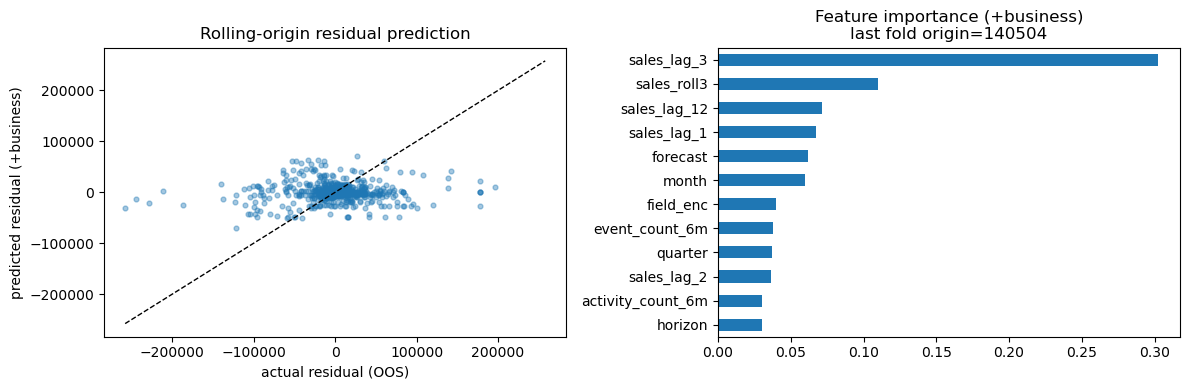

Best PRIMARY OOS RMSE: base_ts (18185.18) vs base_ts (18185.18)
RMSE reduction vs base: 0.0%
Feature importance from last successful fold model (origin=140504)


,model,rmse,mae,mape,wmape
0,base_ts,18185.176166,5992.657516,1627.581097,40.890976
1,xgb_baseline,18603.721190,6142.986958,1555.165679,41.916751
2,xgb_baseline_plus_business,18985.039032,6251.398207,1437.666063,42.656497


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(
    rolling_predictions["residual"],
    rolling_predictions["pred_resid_biz"],
    alpha=0.4,
    s=12,
)
lim = np.nanmax(
    np.abs(rolling_predictions[["residual", "pred_resid_biz"]].to_numpy())
)
axes[0].plot([-lim, lim], [-lim, lim], "k--", lw=1)
axes[0].set_xlabel("actual residual (OOS)")
axes[0].set_ylabel("predicted residual (+business)")
axes[0].set_title("Rolling-origin residual prediction")

imp = pd.Series(model_biz.feature_importances_, index=ALL_FEATURES).sort_values()
imp.tail(12).plot(kind="barh", ax=axes[1])
axes[1].set_title(f"Feature importance (+business)\nlast fold origin={last_fold_origin}")
plt.tight_layout()
plt.show()

winner = overall_oos.sort_values("rmse").iloc[0]["model"]
base_rmse = overall_oos.loc[overall_oos["model"] == "base_ts", "rmse"].iloc[0]
best_rmse = overall_oos["rmse"].min()
print(
    f"Best PRIMARY OOS RMSE: {winner} ({best_rmse:.2f}) vs base_ts ({base_rmse:.2f})"
)
print(f"RMSE reduction vs base: {(base_rmse - best_rmse) / base_rmse * 100:.1f}%")
print(
    f"Feature importance from last successful fold model (origin={last_fold_origin})"
)
overall_oos


## Product / quarter explorer

Pick a `product` and forecast `qrt`, then compare **sales**, base **TS** forecast, **ML** (baseline residual), and **biz ML** (baseline + events/activities).

**Primary series** use out-of-sample predictions from `rolling_predictions` (true origin backtest). If a product/qrt was never an evaluated test origin fold, ML columns are missing and the plot says so — it does not silently fall back to a single global model as primary truth.


In [13]:
import matplotlib.pyplot as plt
from IPython.display import display

# Base panel + OOS rolling predictions (primary). No global in-sample rescoring as primary.
oos_cols = [
    "product",
    "qrt",
    "date",
    "origin",
    "horizon",
    "pred_resid_base",
    "pred_resid_biz",
    "forecast_adj_base",
    "forecast_adj_biz",
    "test_origin",
    "train_date_max",
]
compare_df = feat_model.merge(
    rolling_predictions[oos_cols],
    on=["product", "qrt", "date", "origin", "horizon"],
    how="left",
    suffixes=("", "_oos"),
)
compare_df["ts"] = compare_df["forecast"]
compare_df["ml"] = compare_df["forecast_adj_base"]
compare_df["biz_ml"] = compare_df["forecast_adj_biz"]
compare_df["split"] = np.where(compare_df["test_origin"].notna(), "oos", "not_oos")

available_products = sorted(compare_df["product"].dropna().unique())
available_qrts = sorted(compare_df["qrt"].dropna().unique())
n_oos = int(compare_df["split"].eq("oos").sum())
print(
    f"{len(available_products)} products, quarters: {available_qrts}; "
    f"OOS rows={n_oos} / {len(compare_df)}"
)
compare_df[
    ["product", "qrt", "date", "horizon", "sales", "ts", "ml", "biz_ml", "split"]
].head()


63 products, quarters: ['1403Q1', '1403Q2', '1403Q3', '1403Q4', '1404Q2', '1404Q3', '1404Q4', '1405Q2']; OOS rows=4444 / 5269


,product,qrt,date,horizon,sales,ts,ml,biz_ml,split
0,Aryotrust 150,1403Q1,140304,1,7689.0,6021.0,NaN,NaN,not_oos
1,Aryotrust 150,1403Q1,140305,2,5550.0,6250.0,NaN,NaN,not_oos
2,Aryotrust 150,1403Q1,140306,3,5631.0,6020.0,NaN,NaN,not_oos
3,Aryotrust 150,1403Q2,140306,1,5631.0,6973.0,8769.795166,8376.463867,oos
4,Aryotrust 150,1403Q1,140307,4,4631.0,5943.0,NaN,NaN,not_oos


In [14]:
# --- Select product & quarter (edit these, or use widgets below if available) ---
PRODUCT = available_products[0]
QRT = available_qrts[-1]

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    product_dd = widgets.Dropdown(options=available_products, value=PRODUCT, description="product")
    qrt_dd = widgets.Dropdown(
        options=available_qrts,
        value=QRT if QRT in available_qrts else available_qrts[-1],
        description="qrt",
    )
    out = widgets.Output()

    def _render(product: str, qrt: str):
        with out:
            clear_output(wait=True)
            view = (
                compare_df[(compare_df["product"] == product) & (compare_df["qrt"] == qrt)]
                .sort_values("date")
                .copy()
            )
            if view.empty:
                print(f"No rows for product={product!r}, qrt={qrt!r}")
                return

            cols = ["date", "horizon", "sales", "ts", "ml", "biz_ml", "residual", "split"]
            display(view[cols].reset_index(drop=True))

            n_oos = int(view["split"].eq("oos").sum())
            origin = int(view["origin"].iloc[0])
            print(f"origin={origin}  n={len(view)}  oos_rows={n_oos}")
            if n_oos == 0:
                print(
                    "No rolling-origin OOS predictions for this product/qrt "
                    "(not an evaluated test fold or skipped). Showing TS only for ML series."
                )

            fig, ax = plt.subplots(figsize=(10, 4))
            ax.plot(view["date"].astype(str), view["sales"], "o-", label="sales", color="black")
            ax.plot(view["date"].astype(str), view["ts"], "s--", label="ts", alpha=0.85)
            if view["ml"].notna().any():
                ax.plot(view["date"].astype(str), view["ml"], "^--", label="ml (OOS)", alpha=0.85)
            if view["biz_ml"].notna().any():
                ax.plot(
                    view["date"].astype(str), view["biz_ml"], "d--", label="biz_ml (OOS)", alpha=0.85
                )
            ax.set_title(f"{product} | {qrt}")
            ax.set_xlabel("Shamsi YYYYMM")
            ax.set_ylabel("units")
            ax.legend()
            ax.tick_params(axis="x", rotation=45)
            fig.tight_layout()
            plt.show()

            scored = view.dropna(subset=["ml", "biz_ml"])
            if scored.empty:
                print("No OOS rows to score for this selection.")
            else:
                err = pd.DataFrame(
                    [
                        metrics_block(scored["sales"], scored["ts"], "ts"),
                        metrics_block(scored["sales"], scored["ml"], "ml"),
                        metrics_block(scored["sales"], scored["biz_ml"], "biz_ml"),
                    ]
                )
                display(err)

    def _on_change(_=None):
        _render(product_dd.value, qrt_dd.value)

    product_dd.observe(_on_change, names="value")
    qrt_dd.observe(_on_change, names="value")
    display(widgets.HBox([product_dd, qrt_dd]), out)
    _on_change()
except ImportError:
    print("ipywidgets not installed — set PRODUCT / QRT above and run the next cell.")
    print(f"defaults: PRODUCT={PRODUCT!r}, QRT={QRT!r}")


Output()

,date,horizon,sales,ts,ml,biz_ml,residual,split
0,140504,1,461.0,1243.0,1269.566515,1273.11797,-782.0,oos


origin=140504  n=1  oos_rows=1


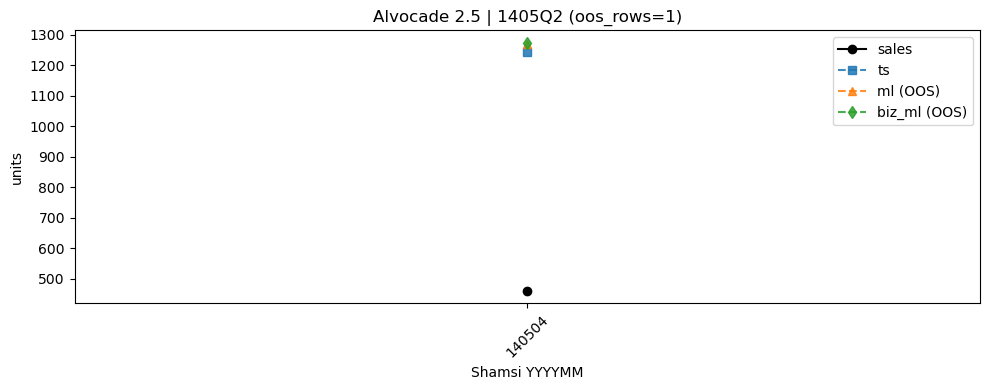

,model,rmse,mae,mape,wmape
0,ts,782.000000,782.000000,169.631236,169.631236
1,ml,808.566515,808.566515,175.394038,175.394038
2,biz_ml,812.117970,812.117970,176.164419,176.164419


In [15]:
# Manual fallback (always works): edit PRODUCT / QRT in the previous cell, then run this
from IPython.display import display

view = (
    compare_df[(compare_df["product"] == PRODUCT) & (compare_df["qrt"] == QRT)]
    .sort_values("date")
    .copy()
)
if view.empty:
    raise ValueError(
        f"No rows for product={PRODUCT!r}, qrt={QRT!r}. "
        f"Try products like {available_products[:5]} / qrts {available_qrts}"
    )

cols = ["date", "horizon", "sales", "ts", "ml", "biz_ml", "residual", "split"]
display(view[cols].reset_index(drop=True))

n_oos = int(view["split"].eq("oos").sum())
print(f"origin={int(view['origin'].iloc[0])}  n={len(view)}  oos_rows={n_oos}")
if n_oos == 0:
    print("No rolling-origin OOS predictions for this product/qrt.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(view["date"].astype(str), view["sales"], "o-", label="sales", color="black")
ax.plot(view["date"].astype(str), view["ts"], "s--", label="ts", alpha=0.85)
if view["ml"].notna().any():
    ax.plot(view["date"].astype(str), view["ml"], "^--", label="ml (OOS)", alpha=0.85)
if view["biz_ml"].notna().any():
    ax.plot(view["date"].astype(str), view["biz_ml"], "d--", label="biz_ml (OOS)", alpha=0.85)
ax.set_title(f"{PRODUCT} | {QRT} (oos_rows={n_oos})")
ax.set_xlabel("Shamsi YYYYMM")
ax.set_ylabel("units")
ax.legend()
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

scored = view.dropna(subset=["ml", "biz_ml"])
if scored.empty:
    print("No OOS rows to score for this selection.")
else:
    display(
        pd.DataFrame(
            [
                metrics_block(scored["sales"], scored["ts"], "ts"),
                metrics_block(scored["sales"], scored["ml"], "ml"),
                metrics_block(scored["sales"], scored["biz_ml"], "biz_ml"),
            ]
        )
    )


In [ ]:



rts